# 01 — Data Foundation: Agents Need a Data Layer, Not a CSV

**Project:** `agentic-aml-investigator` — a multi-agent AML (anti-money-laundering)
investigation copilot built with LangGraph and local Ollama models.

**This notebook** builds the DuckDB warehouse everything else runs on:

1. a **seeded synthetic transaction ledger** (~200 accounts, ~35k transactions, 90 days)
   with **five injected money-laundering typologies**, each recorded in a hidden
   `ground_truth` table,
2. the **real OFAC SDN sanctions list** (~19k entities, downloaded from treasury.gov),
3. **rule-based alerts** — and a look at which typologies rules *catch* vs which ones
   *only an investigation can find* (that gap is the whole reason this project exists).

> **Why synthetic data?** Real AML case data is never public, and the common public
> alternative (PaySim) contains a single fraud pattern — every investigation would look
> identical. A seeded generator gives five distinct labeled typologies, regenerates
> byte-identically on any machine (`seed=42`), and lets us *quantitatively score the
> agent's decisions against ground truth* in notebook 04. The sanctions list, however,
> is the real thing.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from aml_investigator import db                              # warehouse connection helper
from aml_investigator.data.generator import build_warehouse  # seeded ledger + OFAC + alerts
from aml_investigator.settings import settings               # all paths/knobs live here

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (10, 3.5)

# build_warehouse(force=True): generate the synthetic ledger (seed=42), download/cache
# the real OFAC SDN list, derive rule-based alerts, and load it all into a DuckDB file.
# Returns the row count per table. Deterministic — re-running gives identical data.
counts = build_warehouse(force=True)
counts

2026-06-12 18:53:24.704 | INFO     | aml_investigator.data.ofac:download_sdn:26 - SDN list already cached at /home/ahmad/AI/Projects/agentic-aml-investigator/data/raw/sdn.csv


2026-06-12 18:53:27.880 | INFO     | aml_investigator.data.generator:generate_ledger:276 - Generated 200 accounts, 35,253 transactions, 10 labeled accounts


2026-06-12 18:53:28.132 | INFO     | aml_investigator.data.generator:build_warehouse:381 - Warehouse built at /home/ahmad/AI/Projects/agentic-aml-investigator/data/aml.duckdb: {'accounts': 200, 'transactions': 35253, 'sdn': 19065, 'alerts': 11, 'ground_truth': 10}


{'accounts': 200,
 'transactions': 35253,
 'sdn': 19065,
 'alerts': 11,
 'ground_truth': 10}

## The warehouse schema

Five tables matter to the agents (and one is deliberately hidden from them):

| table | rows | who sees it |
|---|---|---|
| `accounts` | KYC profiles | agents |
| `transactions` | the ledger | agents |
| `sdn` | **real** OFAC SDN list | agents |
| `alerts` | rule-engine output | agents |
| `ground_truth` | typology labels | **evaluation only — the SQL guard blocks agents from ever reading it** |

In [2]:
con = db.connect()
con.execute("SELECT * FROM transactions ORDER BY ts LIMIT 5").fetch_df()

,txn_id,ts,account_id,direction,txn_type,amount,counterparty_id,counterparty_name,counterparty_country,channel
0,TXN-018506,2026-03-03 08:01:19,ACC-0095,out,card,149.65,None,"Clark, Hull and Flores",US,pos
1,TXN-031357,2026-03-03 08:02:30,ACC-0180,out,card,48.05,None,Hodges-Gibbs,US,pos
2,TXN-005492,2026-03-03 08:06:39,ACC-0022,out,wire,4026.59,None,Collins Inc,US,online
3,TXN-003667,2026-03-03 08:07:05,ACC-0015,in,transfer,8917.86,None,Foster and Sons,US,online
4,TXN-018762,2026-03-03 08:07:12,ACC-0097,out,card,215.68,None,Taylor and Sons,US,pos


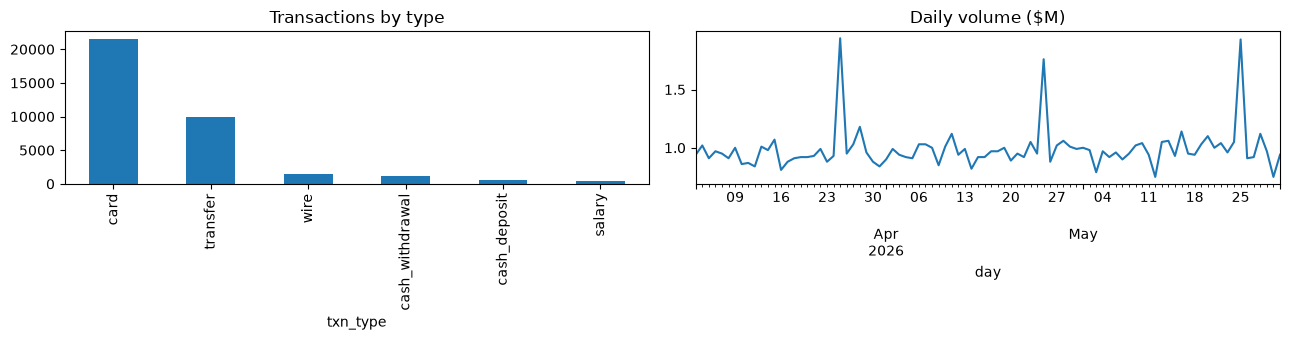

In [3]:
# What does 90 days of bank activity look like?
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
con.execute("""
    SELECT txn_type, count(*) AS n FROM transactions GROUP BY 1 ORDER BY n DESC
""").fetch_df().plot.bar(x="txn_type", y="n", ax=axes[0], legend=False, title="Transactions by type")
con.execute("""
    SELECT CAST(ts AS DATE) AS day, round(sum(amount)/1e6, 2) AS volume_m
    FROM transactions GROUP BY 1 ORDER BY 1
""").fetch_df().plot(x="day", y="volume_m", ax=axes[1], legend=False, title="Daily volume ($M)")
plt.tight_layout()

## The five injected typologies

These are the labeled patterns the agent system will be evaluated against.
The `ground_truth` table records which accounts carry which typology:

In [4]:
con.execute("SELECT * FROM ground_truth ORDER BY typology, account_id").fetch_df()

,account_id,typology,details
0,ACC-0061,circular_transfers,3-account ring ACC-0061 -> ACC-0062 -> ACC-006...
1,ACC-0062,circular_transfers,3-account ring ACC-0061 -> ACC-0062 -> ACC-006...
2,ACC-0063,circular_transfers,3-account ring ACC-0061 -> ACC-0062 -> ACC-006...
3,ACC-0071,funnel_account,"17 unrelated senders, $57,282 funneled then wi..."
4,ACC-0011,sanctioned_counterparty,wires to near-variants of real SDN names: 'Val...
5,ACC-0081,sanctioned_counterparty,wires to near-variants of real SDN names: 'Isl...
6,ACC-0046,structuring,"12 cash deposits in $8.7k-$9.95k band, aggrega..."
7,ACC-0047,structuring,"15 cash deposits in $8.7k-$9.95k band, aggrega..."
8,ACC-0053,velocity_burst,"dormant account, ~$102,662 cycled in/out withi..."
9,ACC-0054,velocity_burst,"dormant account, ~$87,452 cycled in/out within..."


### Typology 1 — Structuring (a.k.a. smurfing)

Cash deposits kept *just under* the $10,000 Currency Transaction Report threshold,
then aggregated and wired out. The histogram makes the evasion visible: a legitimate
cash-intensive business deposits across the whole range (including >$10k, which it
duly reports); the structuring account's deposits pile up in a narrow band below
the line.

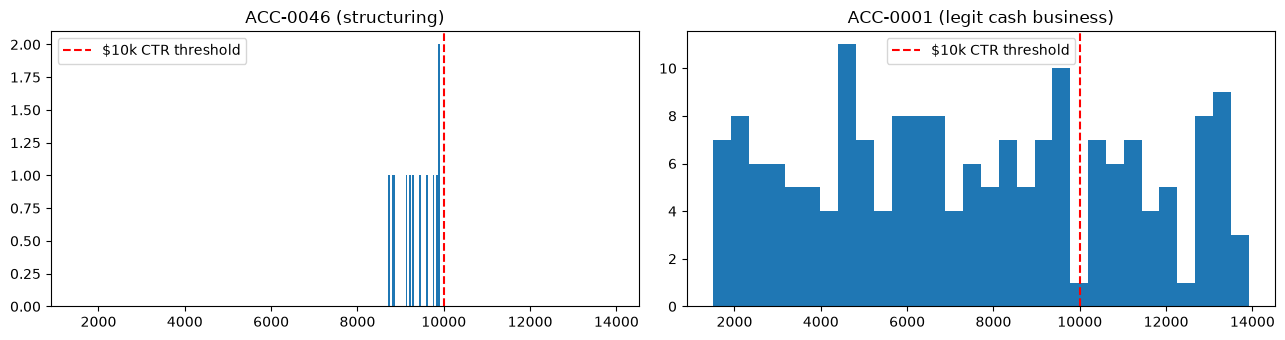

In [5]:
struct_acc = con.execute(
    "SELECT account_id FROM ground_truth WHERE typology = 'structuring' LIMIT 1").fetchone()[0]
cash_biz = con.execute("""
    SELECT t.account_id FROM transactions t LEFT JOIN ground_truth g USING (account_id)
    WHERE t.txn_type = 'cash_deposit' AND g.account_id IS NULL
    GROUP BY 1 ORDER BY count(*) DESC LIMIT 1""").fetchone()[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharex=True)
for ax, acc, title in [(axes[0], struct_acc, f"{struct_acc} (structuring)"),
                       (axes[1], cash_biz, f"{cash_biz} (legit cash business)")]:
    amounts = con.execute(
        "SELECT amount FROM transactions WHERE account_id = ? AND txn_type = 'cash_deposit'",
        [acc]).fetch_df()["amount"]
    ax.hist(amounts, bins=30)
    ax.axvline(10_000, color="red", linestyle="--", label="$10k CTR threshold")
    ax.set_title(title); ax.legend()
plt.tight_layout()

### Typology 2 — Velocity burst

A dormant account (salary credits only) suddenly cycles ~$100k+ in and out within
three days. Daily activity tells the story at a glance:

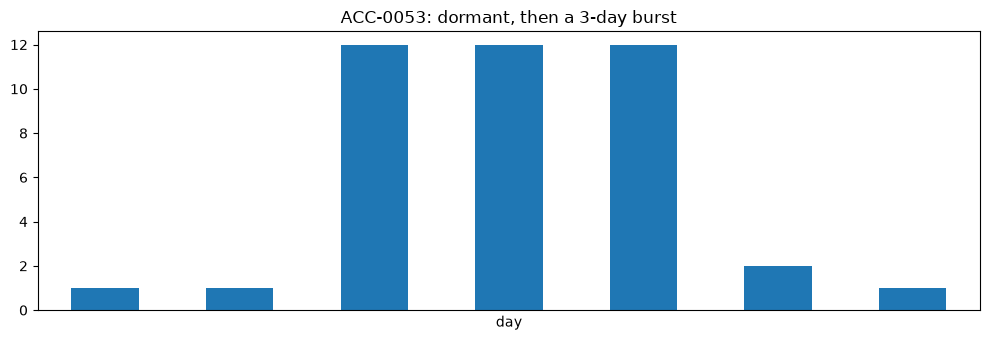

In [6]:
vel_acc = con.execute(
    "SELECT account_id FROM ground_truth WHERE typology = 'velocity_burst' LIMIT 1").fetchone()[0]
daily = con.execute("""
    SELECT CAST(ts AS DATE) AS day, count(*) AS txns FROM transactions
    WHERE account_id = ? GROUP BY 1 ORDER BY 1""", [vel_acc]).fetch_df()
daily.plot.bar(x="day", y="txns", legend=False,
               title=f"{vel_acc}: dormant, then a 3-day burst")
plt.xticks([]); plt.tight_layout()

### Typology 3 — Circular transfers

Three accounts pass nearly the same amount around a ring (A → B → C → A), six times.
No single hop looks odd; the *cycle* is the signal — which is why the
`counterparty_network` tool does ring detection with a recursive SQL self-join.

In [7]:
ring = [r[0] for r in con.execute(
    "SELECT account_id FROM ground_truth WHERE typology = 'circular_transfers' ORDER BY 1").fetchall()]
con.execute("""
    SELECT account_id AS src, counterparty_id AS dst, count(*) AS hops, round(sum(amount)) AS total
    FROM transactions
    WHERE account_id IN (SELECT account_id FROM ground_truth WHERE typology = 'circular_transfers')
          AND direction = 'out' AND txn_type = 'transfer' AND counterparty_id LIKE 'ACC-%'
    GROUP BY 1, 2 HAVING count(*) > 2 ORDER BY 1""").fetch_df()

,src,dst,hops,total
0,ACC-0061,ACC-0062,6,89974.0
1,ACC-0062,ACC-0063,6,90065.0
2,ACC-0063,ACC-0061,6,91200.0


### Typology 4 — Funnel account

Seventeen unrelated senders converge on one account; the balance exits in a single
large wire. Sender concentration is the tell:

In [8]:
funnel_acc = con.execute(
    "SELECT account_id FROM ground_truth WHERE typology = 'funnel_account'").fetchone()[0]
con.execute("""
    SELECT direction, txn_type, count(*) AS n,
           count(DISTINCT coalesce(counterparty_id, counterparty_name)) AS distinct_counterparties,
           round(sum(amount)) AS total
    FROM transactions WHERE account_id = ? GROUP BY 1, 2 ORDER BY total DESC""",
    [funnel_acc]).fetch_df()

,direction,txn_type,n,distinct_counterparties,total
0,in,transfer,17,17,57282.0
1,out,wire,1,1,54991.0
2,in,salary,3,3,18416.0
3,out,card,130,130,14718.0
4,out,transfer,6,6,5205.0
5,out,cash_withdrawal,7,0,700.0


### Typology 5 — Sanctioned counterparty (real OFAC data)

Two accounts wire money to counterparties whose names are **near-variants of real
SDN entries** (one character changed — realistic sanctions evasion). Exact-match
screening misses these; fuzzy matching catches them. Notice how close the planted
names are to the real entries:

In [9]:
con.execute("SELECT details FROM ground_truth WHERE typology = 'sanctioned_counterparty'").fetch_df()

,details
0,wires to near-variants of real SDN names: 'Isl...
1,wires to near-variants of real SDN names: 'Val...


In [10]:
# The real OFAC SDN list is in the warehouse for the agents to screen against
print(con.execute("SELECT count(*) FROM sdn").fetchone()[0], "real SDN entries, e.g.:")
con.execute("SELECT * FROM sdn WHERE sdn_type = 'individual' LIMIT 5").fetch_df()

19065 real SDN entries, e.g.:


,ent_num,sdn_name,sdn_type,program
0,2674,"ABBAS, Abu",individual,SDGT
1,2675,"AL RAHMAN, Shaykh Umar Abd",individual,SDGT
2,2676,"AL ZAWAHIRI, Dr. Ayman",individual,SDGT
3,2677,"AL-ZOMOR, Abboud Abdul Latif Hassan",individual,SDGT
4,2678,"AWDA, Abd Al Aziz",individual,SDGT


## Rule-based alerts — and what rules miss

A classic AML programme runs deterministic rules. Ours implements three (sub-threshold
deposit counting, calendar-baseline velocity spikes, large wires to high-risk
countries). The crucial result is the *coverage gap*:

In [11]:
print(con.execute("""
    SELECT a.rule, count(*) AS alerts,
           sum(CASE WHEN g.account_id IS NOT NULL THEN 1 ELSE 0 END) AS on_labeled_accounts
    FROM alerts a LEFT JOIN ground_truth g USING (account_id) GROUP BY 1""").fetch_df(), "\n")

coverage = con.execute("""
    SELECT g.typology,
           count(DISTINCT g.account_id) AS labeled,
           count(DISTINCT a.account_id) AS with_alert
    FROM ground_truth g LEFT JOIN alerts a USING (account_id)
    GROUP BY 1 ORDER BY 1""").fetch_df()
coverage

                     rule  alerts  on_labeled_accounts
0    large_high_risk_wire       2                  2.0
1          velocity_spike       4                  2.0
2  sub_threshold_deposits       5                  2.0 



,typology,labeled,with_alert
0,circular_transfers,3,0
1,funnel_account,1,0
2,sanctioned_counterparty,2,0
3,structuring,2,2
4,velocity_burst,2,2


**Read that table carefully — it motivates the whole project:**

- `structuring` and `velocity_burst` are caught by rules (and the rules *also* fire
  on legitimate cash businesses and payroll runs — false positives someone must triage).
- `circular_transfers`, `funnel_account` and `sanctioned_counterparty` produce
  **zero alerts**. Rings need graph analysis, funnels need counterparty concentration
  analysis, and evasive sanctions spellings need fuzzy screening — none of which a
  threshold rule does.

In the next notebooks, the agent system handles *both* halves of the problem:
investigating alerts (separating true hits from hard negatives) and running the
deeper forensics that rules can't express. The accounts with no alert enter the
eval set as "periodic KYC review" referrals — exactly how real compliance teams
open rule-less cases.

In [12]:
con.close()